# Imports

In [40]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import matplotlib.dates as mdates
from itertools import combinations
import warnings
warnings.simplefilter("ignore")

# Load Dataset

In [41]:
df = pd.read_csv("Data/uniswap_v3.csv.gz")
df

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,owner,tickLower,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,NaN,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0
3,0.000000,0.000000,0.000000,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,394,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257915,NaN,NaN,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,1768694471,NaN,71.0
4,0.000000,0.000000,0.000000,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,311,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257916,NaN,NaN,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,1768694483,NaN,83.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468187,-534.128831,0.267508,533.992405,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,274,0x0426e3cf11caf15ffcb14c371314359934b6b2ce,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,1772624560944410379271804609024497,200322.0,...,NaN,NaN,NaN,24472822,1.030892e+09,0.0,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,1771286363,5.005402e+08,2591963.0
468188,-532.915750,0.266901,532.780087,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,279,0x0426e3cf11caf15ffcb14c371314359934b6b2ce,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,1772626066969204442031536473429827,200322.0,...,NaN,NaN,NaN,24472822,1.030892e+09,0.0,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,1771286363,5.005402e+08,2591963.0
468189,-0.002684,5.366980,5.362012,0x0631fc60f6b586858de1e3ff18a83c824a6d66aa44e4...,21,0xee608a97b040c341c85afad3e1dd69251eb87035,0x282886d79c7495df43ad3d734b636644a0a3f320,0x282886d79c7495df43ad3d734b636644a0a3f320,3541742137642908127256565,-200320.0,...,NaN,NaN,NaN,24472824,3.114259e+07,0.0,0x0631fc60f6b586858de1e3ff18a83c824a6d66aa44e4...,1771286387,1.998241e-09,2591987.0
468190,-9990.996826,9997.000000,9993.998413,0x05be705aceadfa9f73d35fd8d55e094bf57a291b2fc5...,233,0x43370188473a398394e4ba4a7c7cbb2c6265e22a,0x47f2c56286f81d9b5e438ea7d60eca59b6ec1c69,0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45,79248005948958442658832787685,5.0,...,NaN,NaN,NaN,24472825,5.165245e+07,0.0,0x05be705aceadfa9f73d35fd8d55e094bf57a291b2fc5...,1771286399,1.000500e+00,2591999.0


# Perform Data Analysis

In [42]:
print(df.dtypes)

amount0                    float64
amount1                    float64
amountUSD                  float64
id                          object
logIndex                     int64
origin                      object
recipient                   object
sender                      object
sqrtPriceX96                object
tick                       float64
timestamp                   object
pool                        object
event_type                  object
amount                     float64
owner                       object
tickLower                  float64
tickUpper                  float64
transaction.blockNumber      int64
transaction.gasPrice       float64
transaction.gasUsed        float64
transaction.id              object
transaction.timestamp        int64
price_1_per_0              float64
t                          float64
dtype: object


In [43]:
df.columns

Index(['amount0', 'amount1', 'amountUSD', 'id', 'logIndex', 'origin',
       'recipient', 'sender', 'sqrtPriceX96', 'tick', 'timestamp', 'pool',
       'event_type', 'amount', 'owner', 'tickLower', 'tickUpper',
       'transaction.blockNumber', 'transaction.gasPrice',
       'transaction.gasUsed', 'transaction.id', 'transaction.timestamp',
       'price_1_per_0', 't'],
      dtype='object')

In [44]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

In [45]:
swaps = df[df['event_type'] == 'swap']
mints = df[df['event_type'] == 'mint']
burns = df[df['event_type'] == 'burn']

In [46]:
df['event_type'].value_counts()

event_type
swap    448989
burn     10036
mint      9167
Name: count, dtype: int64

Should investigate the active liquidity of the pool and plot the liquidity profile

In [47]:
df[['amountUSD','amount0','amount1']].describe()

,amountUSD,amount0,amount1
count,4.681920e+05,4.681920e+05,4.681920e+05
mean,3.233954e+04,5.362365e+03,3.767927e+03
std,2.054228e+05,1.191563e+05,7.520230e+04
min,0.000000e+00,-9.754211e+06,-6.000966e+06
25%,1.531563e+02,-5.198416e+01,-7.582806e+00
50%,1.915756e+03,7.560000e-06,2.400027e-03
75%,8.548032e+03,1.088969e+02,1.409878e+01
max,2.582459e+07,5.999400e+06,5.384288e+06


<Axes: title={'center': 'Daily swap volume (USD)'}, xlabel='date'>

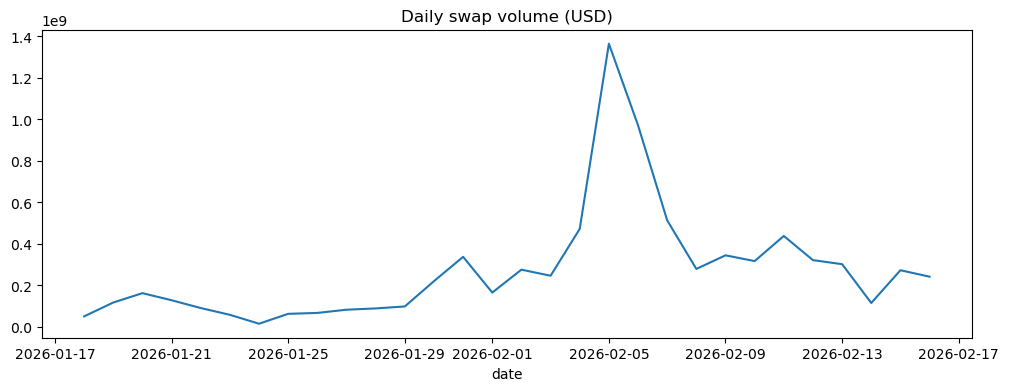

In [48]:
daily = swaps.groupby('date')['amountUSD'].sum()
daily.plot(title='Daily swap volume (USD)', figsize=(12,4))

<Axes: title={'center': 'Price over time'}, xlabel='timestamp'>

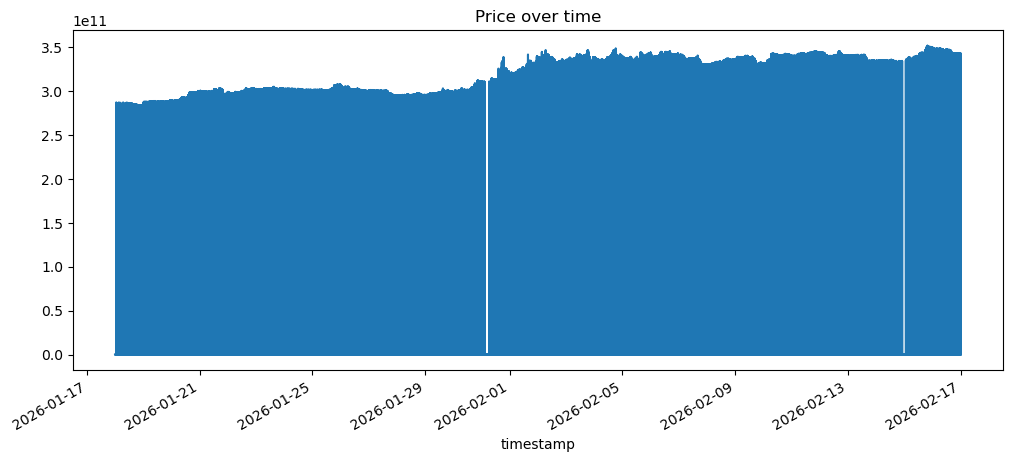

In [49]:
swaps['price'] = 1.0001 ** swaps['tick'] #doit le changer en précisant que je suis sur uniswapV3
swaps.set_index('timestamp')['price'].plot(title='Price over time', figsize=(12,5))

## Events Analysis

In [50]:
lp_events = df[df['event_type'].isin(['mint', 'burn'])].copy()
lp_events['timestamp'] = pd.to_datetime(lp_events['timestamp'])
lp_events = lp_events.sort_values('timestamp')

In [51]:
lp_events['signed_usd'] = np.where(
    lp_events['event_type'] == 'mint',
    lp_events['amountUSD'],
    -lp_events['amountUSD']
)
lp_events['signed_amount0'] = np.where(
    lp_events['event_type'] == 'mint',
    lp_events['amount0'],
    -lp_events['amount0']
)
lp_events['signed_amount1'] = np.where(
    lp_events['event_type'] == 'mint',
    lp_events['amount1'],
    -lp_events['amount1']
)

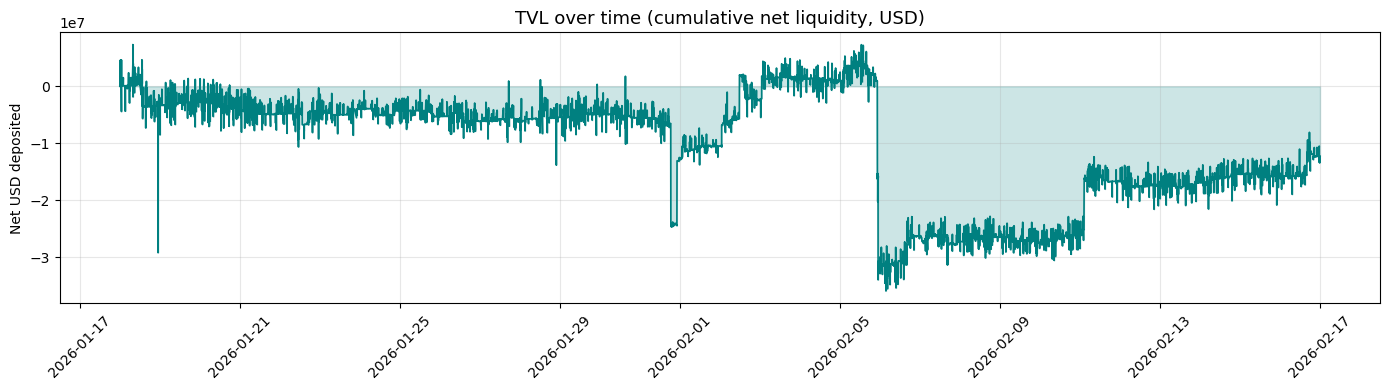

In [52]:
lp_events_sorted = lp_events.sort_values('timestamp')
lp_events_sorted['tvl_usd'] = lp_events_sorted['signed_usd'].cumsum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(lp_events_sorted['timestamp'], lp_events_sorted['tvl_usd'], alpha=0.2, color='teal')
ax.plot(lp_events_sorted['timestamp'], lp_events_sorted['tvl_usd'], linewidth=1.2, color='teal')
ax.set_title("TVL over time (cumulative net liquidity, USD)", fontsize=13)
ax.set_ylabel("Net USD deposited")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

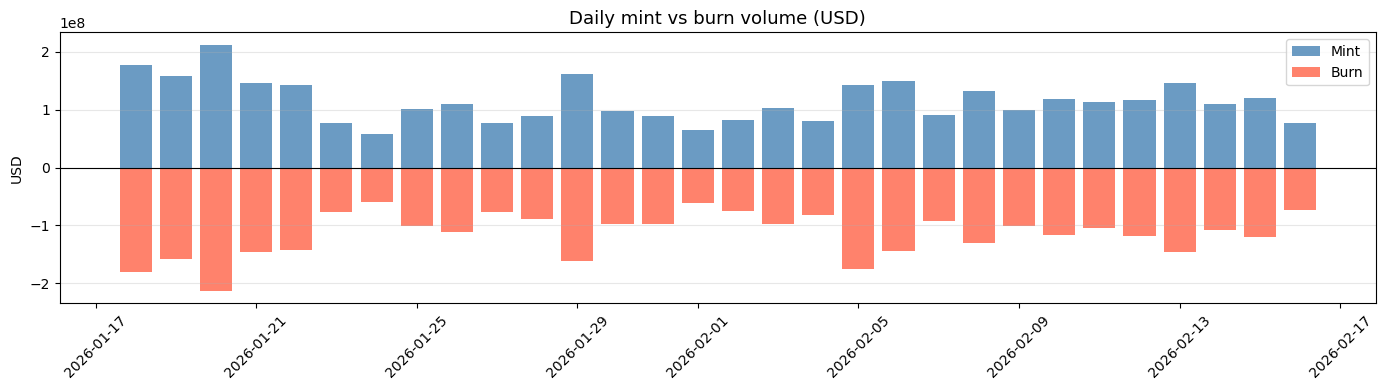

In [53]:
lp_events['date'] = lp_events['timestamp'].dt.date

daily = lp_events.groupby(['date', 'event_type'])['amountUSD'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
if 'mint' in daily.columns:
    ax.bar(daily.index, daily['mint'], label='Mint', color='steelblue', alpha=0.8)
if 'burn' in daily.columns:
    ax.bar(daily.index, -daily['burn'], label='Burn', color='tomato', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Daily mint vs burn volume (USD)", fontsize=13)
ax.set_ylabel("USD")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Tick range width statistics:
count    9.167000e+03
mean     1.744070e+04
std      1.633579e+05
min      1.000000e+00
25%      1.000000e+01
50%      3.600000e+02
75%      2.845000e+03
max      1.774544e+06
Name: tick_width, dtype: float64


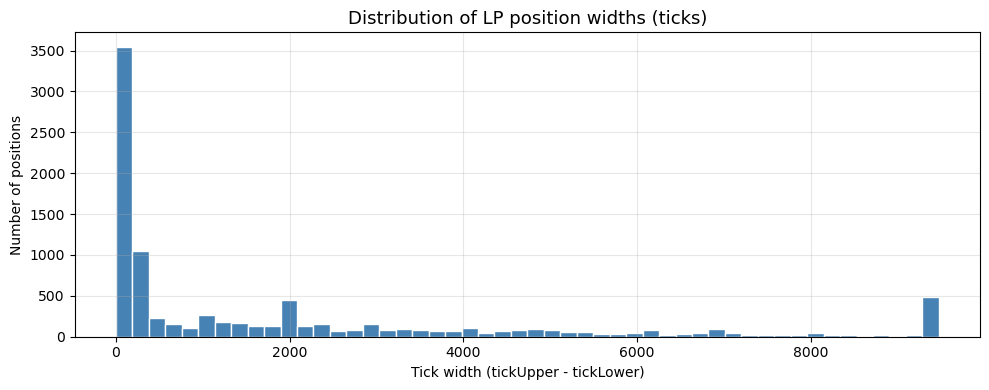

In [54]:
mints = lp_events[lp_events['event_type'] == 'mint'].copy()

mints['tick_width'] = mints['tickUpper'] - mints['tickLower']

mints['price_lower'] = 1.0001 ** mints['tickLower']
mints['price_upper'] = 1.0001 ** mints['tickUpper']

print("Tick range width statistics:")
print(mints['tick_width'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
mints['tick_width'].clip(upper=mints['tick_width'].quantile(0.95)).hist(
    bins=50, ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title("Distribution of LP position widths (ticks)", fontsize=13)
ax.set_xlabel("Tick width (tickUpper - tickLower)")
ax.set_ylabel("Number of positions")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

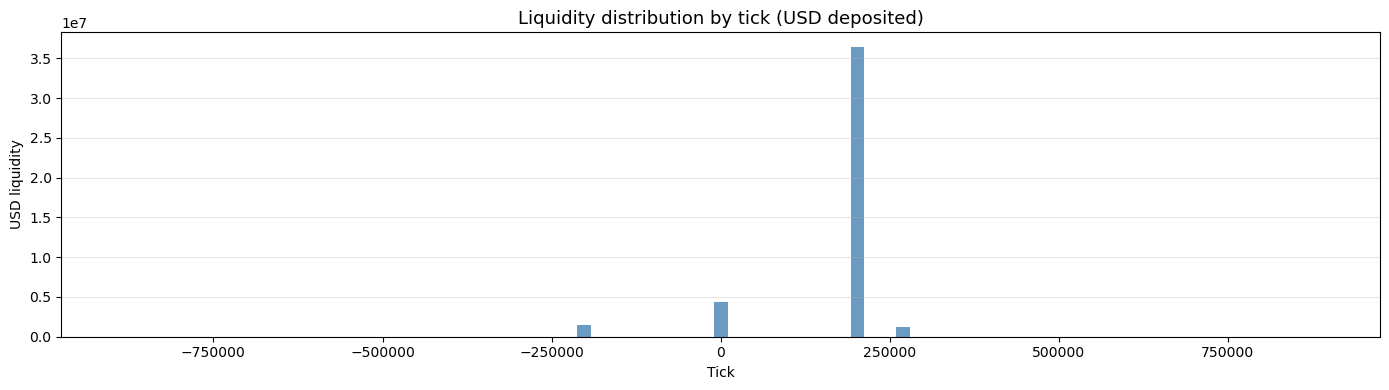

In [55]:
tick_min = mints['tickLower'].min()
tick_max = mints['tickUpper'].max()
bins = np.linspace(tick_min, tick_max, 80)

heatmap = np.zeros(len(bins) - 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

for _, row in mints.iterrows():
    mask = (bin_centers >= row['tickLower']) & (bin_centers <= row['tickUpper'])
    if mask.any():
        heatmap[mask] += row['amountUSD'] / mask.sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(bin_centers, heatmap, width=(bins[1]-bins[0])*0.9, color='steelblue', alpha=0.8)
ax.set_title("Liquidity distribution by tick (USD deposited)", fontsize=13)
ax.set_xlabel("Tick")
ax.set_ylabel("USD liquidity")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [56]:
id_col = 'owner' if lp_events['owner'].notna().sum() > 0 else 'sender'

lp_summary = (
    lp_events.groupby([id_col, 'event_type'])['amountUSD']
    .sum()
    .unstack(fill_value=0)
    .rename(columns={'mint': 'total_minted_usd', 'burn': 'total_burned_usd'})
)

for col in ['total_minted_usd', 'total_burned_usd']:
    if col not in lp_summary.columns:
        lp_summary[col] = 0

lp_summary['net_usd'] = (
    lp_summary['total_minted_usd'] - lp_summary['total_burned_usd']
)

lp_summary['n_mints'] = (
    lp_events[lp_events['event_type']=='mint']
    .groupby(id_col)
    .size()
)

lp_summary['n_burns'] = (
    lp_events[lp_events['event_type']=='burn']
    .groupby(id_col)
    .size()
)

lp_summary['withdrawal_rate'] = (
    lp_summary['total_burned_usd'] /
    lp_summary['total_minted_usd'].replace(0, 1)
).clip(0, 1)

lp_summary = lp_summary.fillna(0).sort_values('total_minted_usd', ascending=False)

print(f"Total unique LPs: {len(lp_summary)}")
print(f"\nTop 10 LPs by total minted USD:")
print(lp_summary.head(10).to_string())

Total unique LPs: 21

Top 10 LPs by total minted USD:
event_type                                  total_burned_usd  total_minted_usd       net_usd  n_mints  n_burns  withdrawal_rate
owner                                                                                                                          
0x1f2f10d1c40777ae1da742455c65828ff36df387      3.006986e+09      3.006886e+09 -9.977361e+04   1820.0     1820         1.000000
0xc36442b4a4522e871399cd717abdd847ab11fe88      2.595094e+08      2.476368e+08 -1.187259e+07   7187.0     8041         1.000000
0x28ac01d4790ed04b378ca32c90e443b3cb6358cd      1.615896e+08      1.616143e+08  2.473631e+04     50.0       50         0.999847
0x263dc5b7b0f2e433b03964f6288344ef8dc952e4      9.211922e+06      9.201997e+06 -9.924674e+03     12.0       12         1.000000
0x6dc71298ce1b61ba4c83d5cdf4b3b1e9aa558a7f      8.947558e+06      8.941071e+06 -6.486881e+03     15.0       15         1.000000
0xc30f6ee36a1746dd71c7e81529eeae7ce2f52252      4.

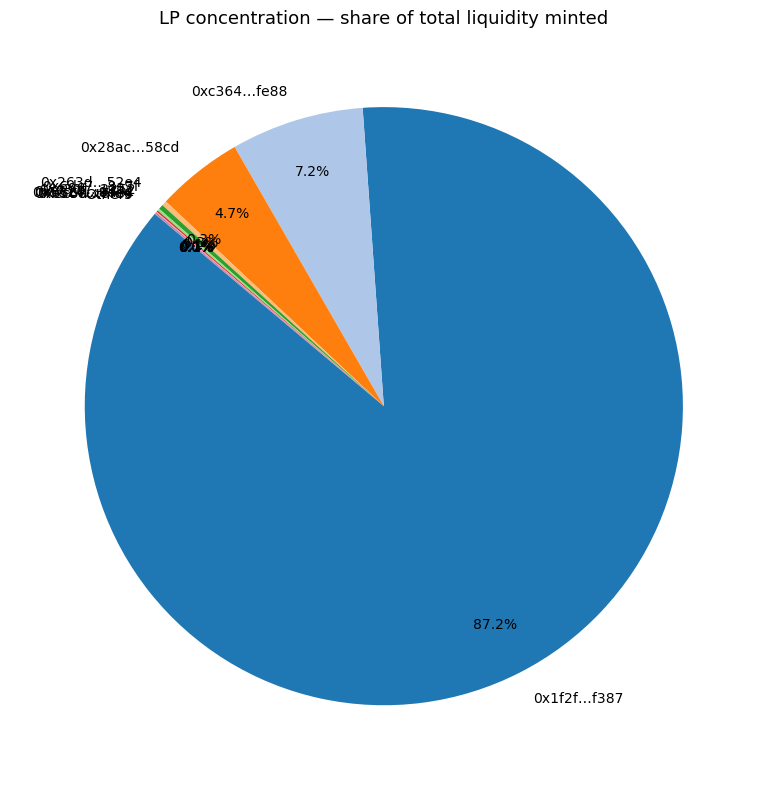

In [57]:
top_n = 10
top_lps = lp_summary['total_minted_usd'].head(top_n)
others  = lp_summary['total_minted_usd'].iloc[top_n:].sum()

labels = [f"{addr[:6]}…{addr[-4:]}" for addr in top_lps.index] + ['Others']
sizes  = list(top_lps.values) + [others]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    colors=plt.cm.tab20.colors[:len(sizes)]
)
ax.set_title("LP concentration — share of total liquidity minted", fontsize=13)
plt.tight_layout()
plt.show()

In [58]:
mints_pos = mints[[id_col, 'tickLower', 'tickUpper', 'amountUSD', 'timestamp']].copy()
mints_pos.columns = [id_col, 'tickLower', 'tickUpper', 'mint_usd', 'mint_time']

burns = lp_events[lp_events['event_type'] == 'Burn'].copy()
burns_pos = burns[[id_col, 'tickLower', 'tickUpper', 'amountUSD', 'timestamp']].copy()
burns_pos.columns = [id_col, 'tickLower', 'tickUpper', 'burn_usd', 'burn_time']

positions = mints_pos.merge(burns_pos, on=[id_col, 'tickLower', 'tickUpper'], how='left')
positions['duration_days'] = (
    positions['burn_time'] - positions['mint_time']
).dt.total_seconds() / 86400

closed = positions.dropna(subset=['burn_time'])
open_  = positions[positions['burn_time'].isna()]

print(f"Closed positions: {len(closed)}")
print(f"Still open positions: {len(open_)}")
if len(closed) > 0:
    print(f"\nMedian holding duration: {closed['duration_days'].median():.1f} days")
    print(f"Mean holding duration:   {closed['duration_days'].mean():.1f} days")

    fig, ax = plt.subplots(figsize=(10, 4))
    closed['duration_days'].clip(upper=closed['duration_days'].quantile(0.95)).hist(
        bins=40, ax=ax, color='mediumseagreen', edgecolor='white'
    )
    ax.set_title("LP position holding duration (days)", fontsize=13)
    ax.set_xlabel("Days open")
    ax.set_ylabel("Number of positions")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Closed positions: 0
Still open positions: 9167


# Detecting MEV attacks

In this section, we will try to detect JIT and Sandwich attacks using the methods proposed in the paper : Deviations from Tradition: Stylized Facts in the Era of DeFi from Maria Di Nosse & al. 

https://arxiv.org/pdf/2510.22834v1

In [85]:
swaps = df[df['event_type'] == 'swap'].copy()
swaps['timestamp'] = pd.to_datetime(swaps['timestamp'])
swaps = swaps.sort_values(['transaction.blockNumber', 'logIndex'])

In [86]:
print(len(swaps))

448989


In [76]:
swaps['direction'] = np.sign(swaps['amount0'])

In [77]:
swaps['abs_usd'] = swaps['amountUSD'].abs()

In [78]:
print(f"Total swaps:  {len(swaps)}")
print(f"Total blocks: {swaps['transaction.blockNumber'].nunique()}")
print(f"Swaps/block (mean): {len(swaps) / swaps['transaction.blockNumber'].nunique():.2f}")

Total swaps:  448989
Total blocks: 143608
Swaps/block (mean): 3.13


In [79]:
def detect_sandwiches(swaps_df):
    records = []

    for block, group in swaps_df.groupby('transaction.blockNumber'):
        group = group.reset_index(drop=True)
        if len(group) < 3:
            continue

        txs = group.to_dict('records')

        for i in range(len(txs) - 2):
            front  = txs[i]
            victim = txs[i + 1]
            back   = txs[i + 2]

            # Attacker frontrun and backrun must be same sender
            if front['sender'] != back['sender']:
                continue

            # Attacker must differ from victim
            if front['sender'] == victim['sender']:
                continue

            # Frontrun and backrun must be opposite directions
            if front['direction'] == back['direction']:
                continue

            # Frontrun and victim must be same direction
            if front['direction'] != victim['direction']:
                continue

            # Profit estimate: attacker bought at lower price, sold at higher
            # Approximate as: |backrun USD| - |frontrun USD|
            estimated_profit = back['abs_usd'] - front['abs_usd']

            records.append({
                'block':              block,
                'attacker':           front['sender'],
                'victim':             victim['sender'],
                'frontrun_tx':        front['transaction.id'],
                'victim_tx':          victim['transaction.id'],
                'backrun_tx':         back['transaction.id'],
                'frontrun_usd':       front['abs_usd'],
                'victim_usd':         victim['abs_usd'],
                'backrun_usd':        back['abs_usd'],
                'estimated_profit':   estimated_profit,
                'frontrun_logIndex':  front['logIndex'],
                'victim_logIndex':    victim['logIndex'],
                'backrun_logIndex':   back['logIndex'],
                'timestamp':          victim['timestamp'],
            })

    return pd.DataFrame(records)

sandwiches = detect_sandwiches(swaps)
print(f"Sandwich attacks detected: {len(sandwiches)}")
print(f"Unique attackers:          {sandwiches['attacker'].nunique()}")
print(f"Unique victims:            {sandwiches['victim'].nunique()}")
print(f"\nTop 5 by estimated profit:")
print(sandwiches.nlargest(5, 'estimated_profit')[
    ['block', 'attacker', 'victim_usd', 'estimated_profit']
].to_string())

Sandwich attacks detected: 2121
Unique attackers:          80
Unique victims:            166

Top 5 by estimated profit:
         block                                    attacker    victim_usd  estimated_profit
1492  24403514  0xfbd4cdb413e45a52e2c8312f670e9ce67e794c37   6209.650297     513556.857078
1412  24399314  0x66a9893cc07d91d95644aedd05d03f95e1dba8af  52525.511770     291707.495687
75    24277089  0x1f2f10d1c40777ae1da742455c65828ff36df387  29686.889278     279644.726299
1114  24391559  0x66a9893cc07d91d95644aedd05d03f95e1dba8af   5997.952424     250311.292370
935   24384403  0xfbd4cdb413e45a52e2c8312f670e9ce67e794c37  18669.708707     225958.794149


In [80]:
print((len(sandwiches)/len(swaps))*100, '%')

0.47239464663945 %


In [81]:
import pandas as pd

def detect_sandwich_attacks(pool: pd.DataFrame):
    sands = []

    # Ensure proper sorting
    pool = pool.sort_values(["transaction.blockNumber", "logIndex"])

    # Loop over blocks
    for block_number, block in pool.groupby("transaction.blockNumber"):

        # Keep only swaps
        swaps = block[
            block["event_type"].isin(["swap", "swap"])
        ].copy()

        if len(swaps) < 3:
            continue

        swaps = swaps.sort_values("logIndex").reset_index(drop=True)

        # Iterate over potential front runs
        for i, front in swaps.iterrows():

            front_type = front["event_type"]
            front_wallet = front["origin"]
            front_log = front["logIndex"]

            # Determine expected back-run type
            if front_type == "swap":
                back_type = "swap"
            else:
                back_type = "swap"

            # Find candidate back-runs AFTER front
            candidates = swaps[
                (swaps["logIndex"] > front_log) &
                (swaps["event_type"] == back_type) &
                (swaps["origin"] == front_wallet)
            ]

            if candidates.empty:
                continue

            # Take the first valid back-run
            back = candidates.iloc[0]
            back_log = back["logIndex"]

            # Victims = swaps strictly between front and back
            victims = swaps[
                (swaps["logIndex"] > front_log) &
                (swaps["logIndex"] < back_log)
            ]

            if not victims.empty:
                sands.append({
                    "block": block_number,
                    "front": front,
                    "back": back,
                    "victims": victims
                })

    return sands

In [ ]:
sandwiches = detect_sandwich_attacks(df)

print(f"Detected {len(sandwiches)} sandwich attacks")

s = sandwiches[0]
print("Front:", s["front"]["transaction.id"])
print("Back:", s["back"]["transaction.id"])
print("Victims count:", len(s["victims"]))

Detected 386 sandwich attacks
Front: 0x2f07dc4a5ce1612d54bf5aae551504249b09f5235c7eab11e341b561fbdcd28d
Back: 0x2273395a084d3b567d39caaf306d73463df7b009de6e475c2bfb3e1fb9f68d6a
Victims count: 1


Using the algorithm provided in the reference 4 of the class material, section 3.1 of the paper we tried to detect JIT-Attacks

In [84]:
MATCH_COLS = ['tickLower', 'tickUpper', 'amount0', 'amount1']

jit_records = []

for block_num, block in df.groupby('transaction.blockNumber'):
    mints  = block[block['event_type'] == 'mint']
    burns  = block[block['event_type'] == 'burn']
    swaps  = block[block['event_type'] == 'swap']

    if mints.empty or burns.empty or swaps.empty:
        continue

    for _, mint in mints.iterrows():
        matching_burns = burns[
            (burns['logIndex'] > mint['logIndex']) &
            (burns['tickLower']  == mint['tickLower']) &
            (burns['tickUpper']  == mint['tickUpper']) &
            (burns['amount0'].abs().round(6) == np.round(abs(mint['amount0']),6)) &
            (burns['amount1'].abs().round(6) == np.round(abs(mint['amount1']),6))
        ]

        if matching_burns.empty:
            continue

        burn = matching_burns.iloc[0] 

        swaps_between = swaps[
            (swaps['logIndex'] > mint['logIndex']) &
            (swaps['logIndex'] < burn['logIndex'])
        ]

        if swaps_between.empty:
            continue

        jit_records.append({
            'block':               block_num,
            'lp':                  mint.get('origin') or mint.get('sender'),
            'mint_logIndex':       mint['logIndex'],
            'burn_logIndex':       burn['logIndex'],
            'tickLower':           mint['tickLower'],
            'tickUpper':           mint['tickUpper'],
            'mint_amountUSD':      mint['amountUSD'],
            'burn_amountUSD':      burn['amountUSD'],
            'amount_minted':       mint['amount'],
            'n_swaps_between':     len(swaps_between),
            'swaps_volume_usd':    swaps_between['amountUSD'].sum(),
            'timestamp':           mint['timestamp'],
        })

jit = pd.DataFrame(jit_records)
print(f"JIT attacks detected:  {len(jit)}")

JIT attacks detected:  0


In [ ]:
def detect_extended_sandwiches(swaps_df):
    records = []

    for block, group in swaps_df.groupby('transaction.blockNumber'):
        group = group.reset_index(drop=True)
        if len(group) < 3:
            continue

        senders  = group['sender'].tolist()
        dirs     = group['direction'].tolist()
        usd_vals = group['abs_usd'].tolist()
        tx_ids   = group['transaction.id'].tolist()

        for i in range(len(group)):
            for j in range(i + 2, len(group)):
                # Same sender at position i and j, different direction
                if senders[i] != senders[j]:
                    continue
                if dirs[i] == dirs[j]:
                    continue

                # Everything between i and j must be different sender, same direction as i
                middle = range(i + 1, j)
                if not middle:
                    continue

                victims = [
                    k for k in middle
                    if senders[k] != senders[i] and dirs[k] == dirs[i]
                ]
                non_victims = [
                    k for k in middle
                    if k not in victims
                ]

                # Reject if there are unrelated txs sandwiched in between
                if non_victims:
                    continue
                if not victims:
                    continue

                total_victim_usd  = sum(usd_vals[k] for k in victims)
                estimated_profit  = usd_vals[j] - usd_vals[i]

                records.append({
                    'block':             block,
                    'attacker':          senders[i],
                    'n_victims':         len(victims),
                    'frontrun_usd':      usd_vals[i],
                    'total_victim_usd':  total_victim_usd,
                    'backrun_usd':       usd_vals[j],
                    'estimated_profit':  estimated_profit,
                    'frontrun_tx':       tx_ids[i],
                    'backrun_tx':        tx_ids[j],
                    'victim_txs':        [tx_ids[k] for k in victims],
                })

    return pd.DataFrame(records)

ext_sandwiches = detect_extended_sandwiches(swaps)
print(f"Extended sandwiches detected: {len(ext_sandwiches)}")
if len(ext_sandwiches):
    print(ext_sandwiches['n_victims'].value_counts().rename('count').to_frame())

Extended sandwiches detected: 2697
           count
n_victims       
1           2121
2            407
3            104
4             31
5             15
6              6
7              4
8              3
9              2
11             2
39             1
15             1


Blocks with suspicious gas spread: 14361


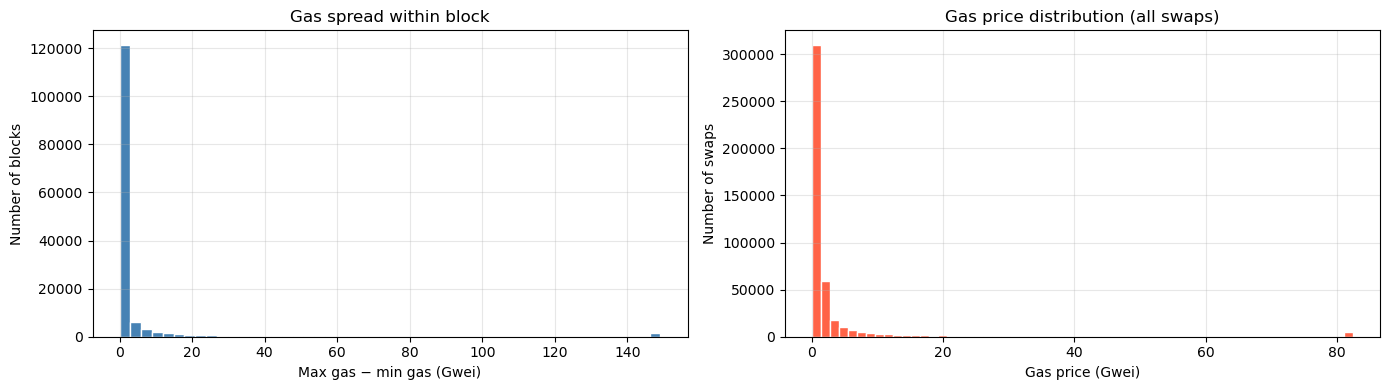

In [ ]:
swaps['gas_cost_gwei'] = swaps['transaction.gasPrice'] / 1e9

# Blocks with multiple swaps: compare gas prices within block
block_gas = swaps.groupby('transaction.blockNumber').agg(
    n_swaps       = ('abs_usd', 'count'),
    max_gas       = ('gas_cost_gwei', 'max'),
    min_gas       = ('gas_cost_gwei', 'min'),
    mean_gas      = ('gas_cost_gwei', 'mean'),
).reset_index()

block_gas['gas_spread'] = block_gas['max_gas'] - block_gas['min_gas']

# Blocks with high gas spread = likely ordering manipulation
high_spread = block_gas[block_gas['gas_spread'] > block_gas['gas_spread'].quantile(0.90)]
print(f"Blocks with suspicious gas spread: {len(high_spread)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(block_gas['gas_spread'].clip(upper=block_gas['gas_spread'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Gas spread within block", fontsize=12)
axes[0].set_xlabel("Max gas − min gas (Gwei)")
axes[0].set_ylabel("Number of blocks")
axes[0].grid(True, alpha=0.3)

# Gas price distribution: MEV bots create a high-gas tail
axes[1].hist(swaps['gas_cost_gwei'].clip(upper=swaps['gas_cost_gwei'].quantile(0.99)),
             bins=60, color='tomato', edgecolor='white')
axes[1].set_title("Gas price distribution (all swaps)", fontsize=12)
axes[1].set_xlabel("Gas price (Gwei)")
axes[1].set_ylabel("Number of swaps")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
if len(sandwiches):
    # Price impact = price shift between frontrun and victim
    # Approximate via tick if available
    sandwiches_with_ticks = sandwiches.merge(
        swaps[['transaction.id', 'tick', 'abs_usd']].rename(columns={
            'transaction.id': 'frontrun_tx', 'tick': 'tick_front', 'abs_usd': 'usd_front'
        }),
        on='frontrun_tx', how='left'
    ).merge(
        swaps[['transaction.id', 'tick']].rename(columns={
            'transaction.id': 'victim_tx', 'tick': 'tick_victim'
        }),
        on='victim_tx', how='left'
    )

    sandwiches_with_ticks['tick_shift'] = (
        sandwiches_with_ticks['tick_victim'] - sandwiches_with_ticks['tick_front']
    ).abs()

    print("Tick shift forced on victims (price impact):")
    print(sandwiches_with_ticks['tick_shift'].describe())
    print(f"\nTotal estimated MEV extracted (USD): {sandwiches['estimated_profit'].sum():,.2f}")
    print(f"Median profit per sandwich (USD):    {sandwiches['estimated_profit'].median():,.2f}")

Tick shift forced on victims (price impact):
count      2700.000000
mean     143915.838889
std      178607.189954
min           0.000000
25%           1.000000
50%          25.000000
75%      393381.750000
max      466514.000000
Name: tick_shift, dtype: float64

Total estimated MEV extracted (USD): -75,100,227.21
Median profit per sandwich (USD):    -5,116.48
